***OVERVIEW***

**Capstone : Heart Attack Risk Prediction**

**Problem Context** : 

India is dealing with a big rise in two major health issues: Type 2 Diabetes and heart disease.

These two problems are very connected. If you can't control your blood sugar, you're much more likely to have a heart attack. So, to deal with one, you have to understand the other.

The goal is to move from just reacting to emergencies (like a heart attack) to a more proactive approach. This means identifying people who are at high risk early on and helping them with preventative care to stop these problems before they start.

**Problem statement**

"How accurately can we use AI to predict heart attack risk for people in India? And when we look at all the health factors, just how much bigger of a red flag is diabetes compared to everything else?"

**Data Source**

Dataset: https://www.kaggle.com/datasets/khushikyad001/heart-attack-risk-prediction-dataset-india



In [26]:
#library imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve



***Exploratory Data analysis***

**Prepare the data**
     1. Load the heart-attack dataset and checked its shape (rows and columns).
     
     2. Review the target column to see how many low-risk and high-risk patients exist
     
     3. Checked for missing values and duplicate rows.
     
     4. This step helps make sure the data is clean enough to continue with analysis

In [27]:
# Step - 1: Load the data set for evaluation. 
df = pd.read_csv('Data/heart_attack_india_3000.csv')
target_col = "target"
#understand the data
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))
print(df.head())

Shape: (3000, 25)

Target distribution:
target
0    1616
1    1384
Name: count, dtype: int64
   patient_id  age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
0           1   68    1   0       160   206    0        1       81      1   
1           2   58    1   0       102   232    1        1      198      1   
2           3   44    1   3       104   215    0        1      166      1   
3           4   72    1   2       178   299    0        0      173      0   
4           5   37    1   2       176   169    1        0      142      1   

   ...  obesity  diabetes  hypertension  family_history  physical_activity  \
0  ...        0         0             0               1                  0   
1  ...        0         1             1               1                  2   
2  ...        0         1             1               1                  0   
3  ...        1         1             0               1                  1   
4  ...        0         1             1               

In [28]:
# Step - 1.1 : Clean the data

print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

dups = df.duplicated().sum()
print("\nDuplicate rows:", dups)
if dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("After drop duplicates:", df.shape)


Missing values (top 10):
patient_id                0
thal                      0
chest_pain_severity       0
air_pollution_exposure    0
alcohol_use               0
diet_quality              0
physical_activity         0
family_history            0
hypertension              0
diabetes                  0
dtype: int64

Duplicate rows: 0


***Target Distribution***

Goal : understand the target distribution, understand the nubmber of patients with risk or not**
Exclude : patient_id, age and target_col 
Provides a quick understanding of overall dataset structure




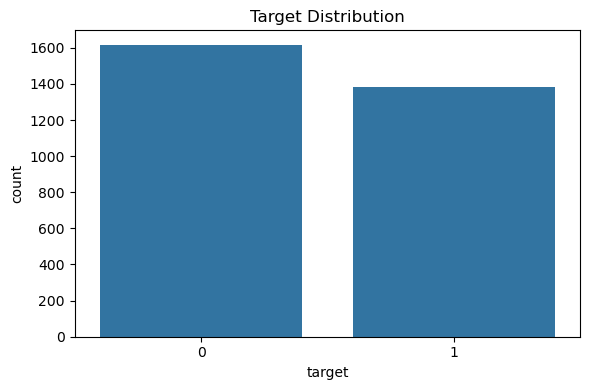

In [29]:
# Step 2: target distribution plots 
# Understnd the factors that impact 
target_column = "target"
exclude_columns_for_plots = ["patient_id", "age", target_col]   # patient id, age and risk target is not considered as they are not important
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

***Step 3: Feature Distribution***
- Visualize how each feature varies across the target variable.
- Exclude patient_id and age from analysis.
- Separate features into true numeric and categorical-like (≤10 unique values).
- Use histograms (numeric) and count plots (categorical) grouped by target.


Numeric columns (true): ['trestbps', 'chol', 'thalach', 'oldpeak', 'air_pollution_exposure']

Categorical-like columns: ['alcohol_use', 'ca', 'chest_pain_severity', 'cp', 'diabetes', 'diet_quality', 'exang', 'family_history', 'fbs', 'hypertension', 'obesity', 'physical_activity', 'restecg', 'sex', 'slope', 'smoking', 'thal']


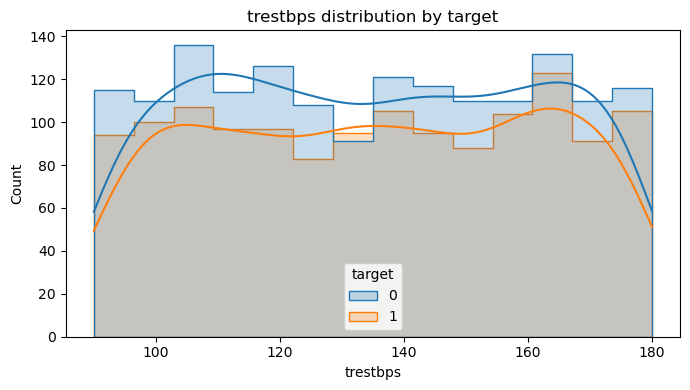

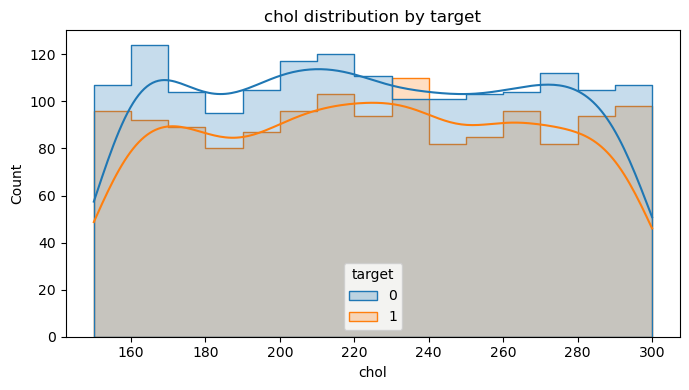

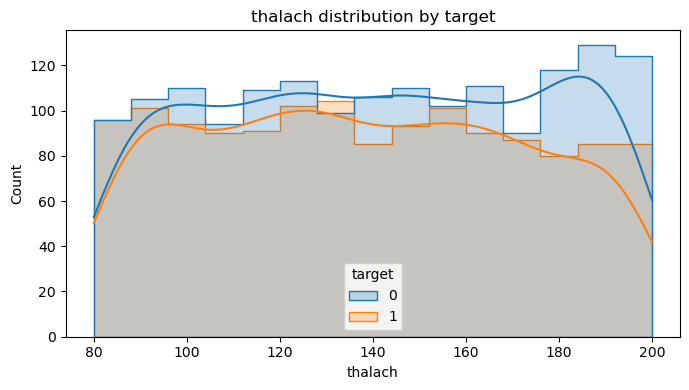

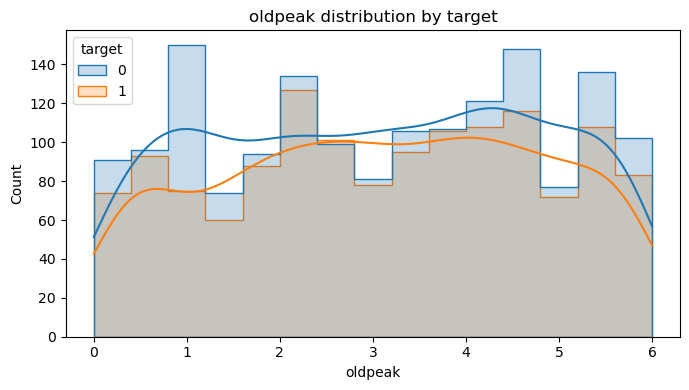

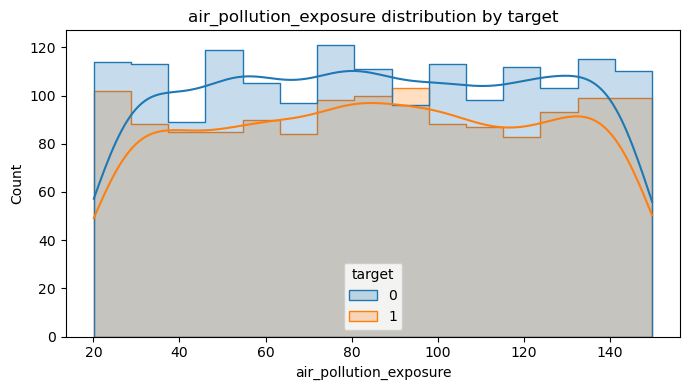

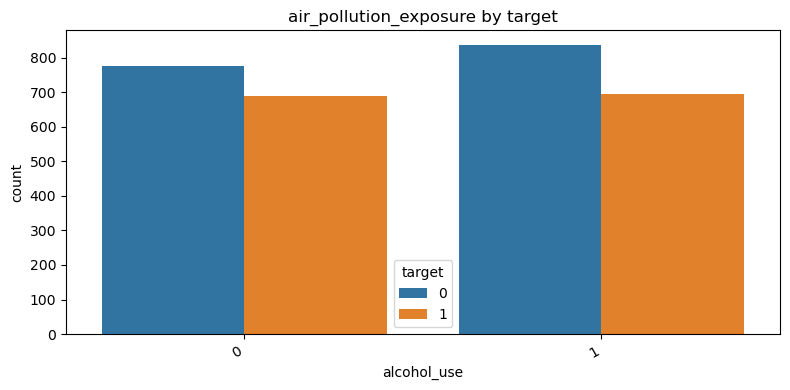

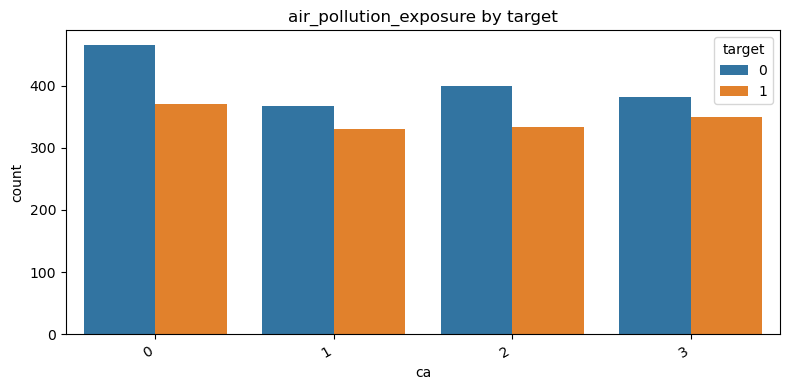

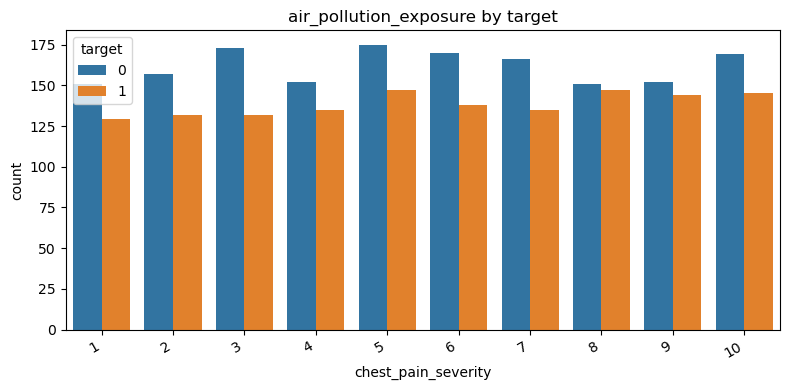

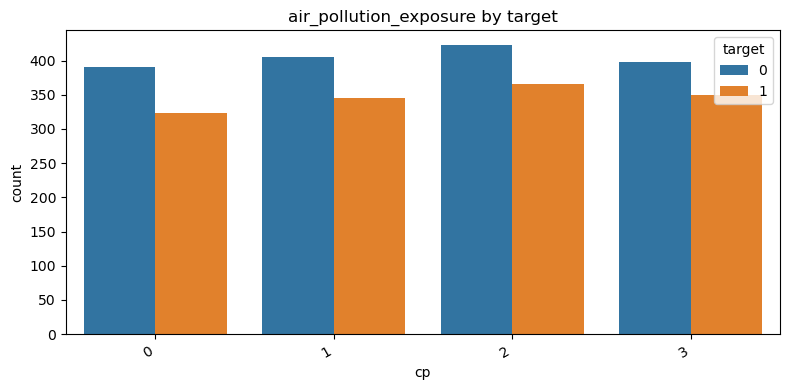

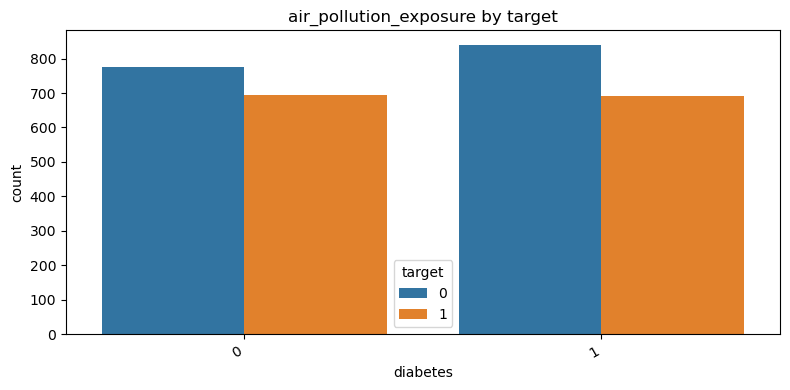

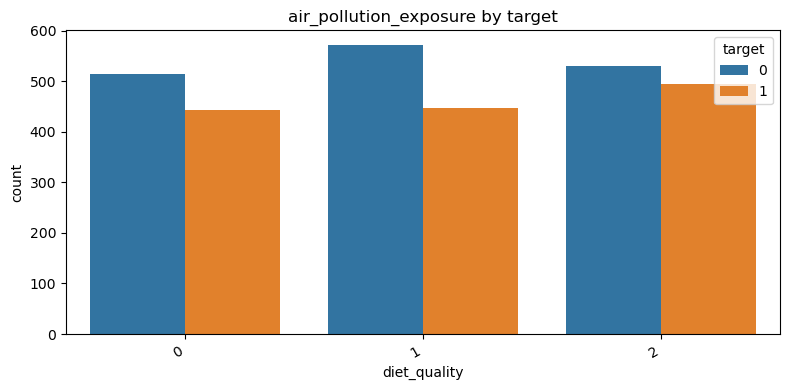

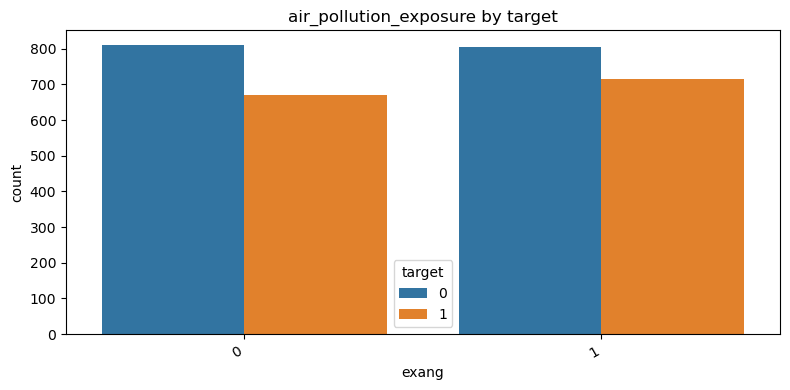

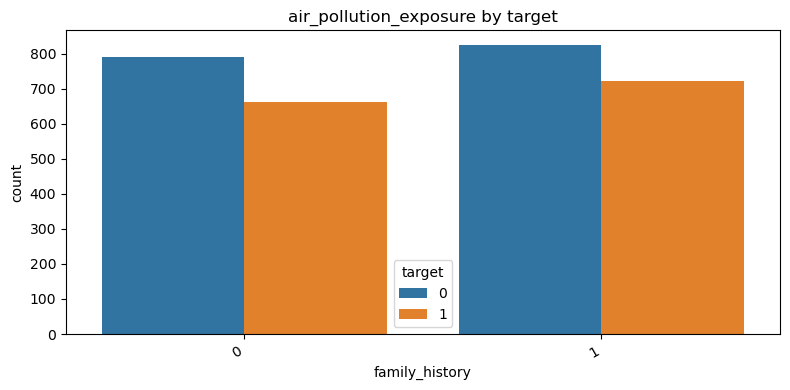

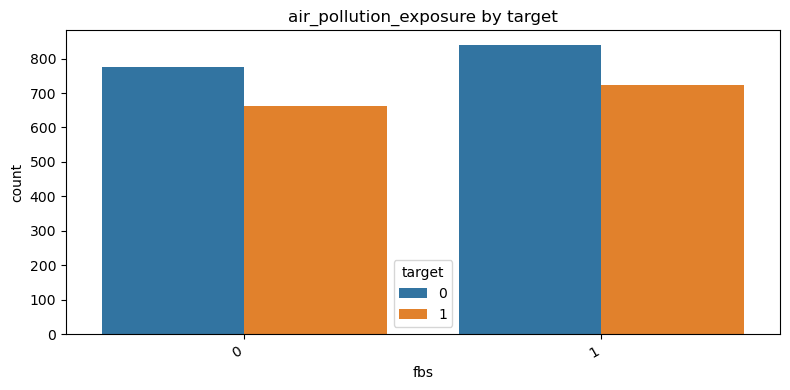

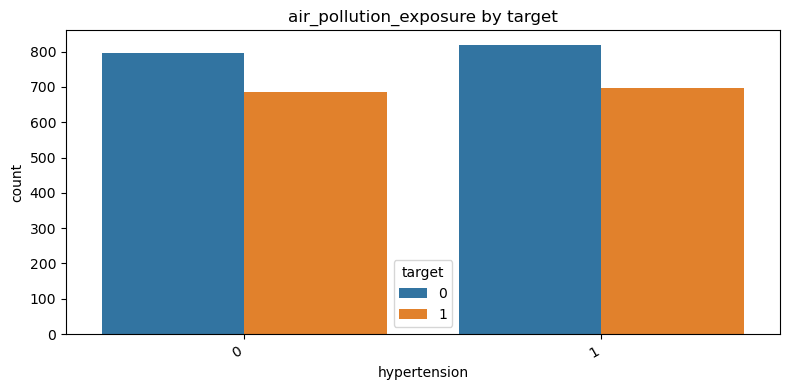

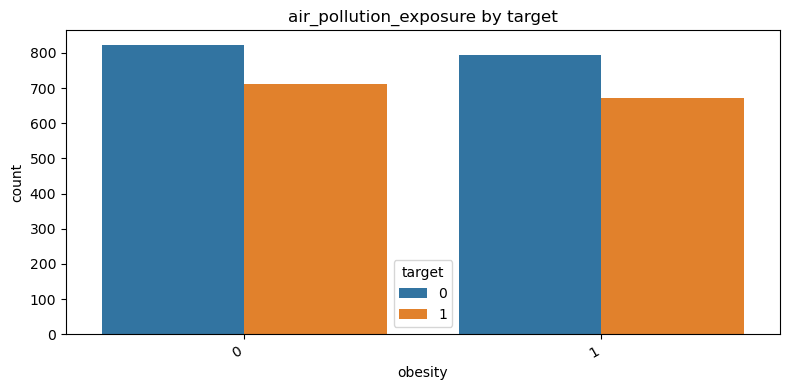

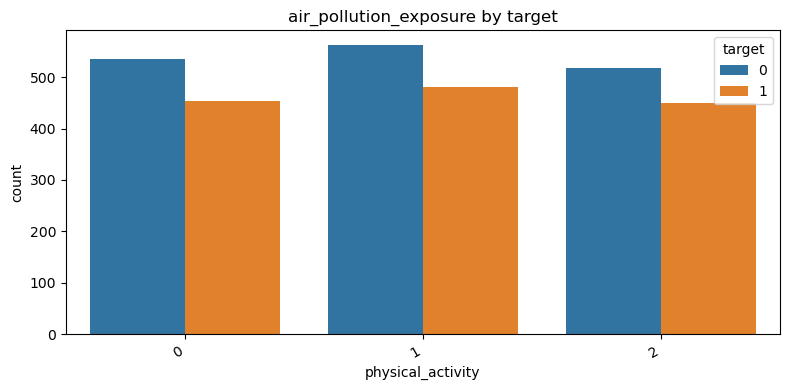

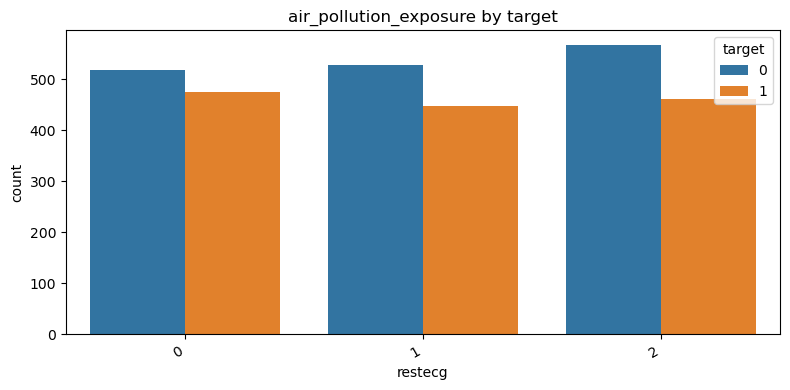

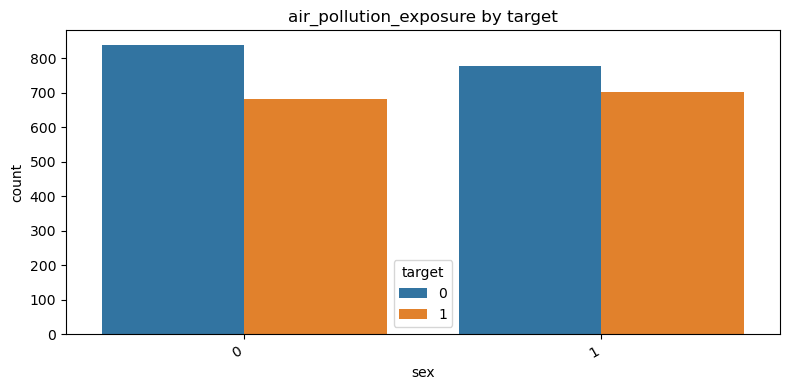

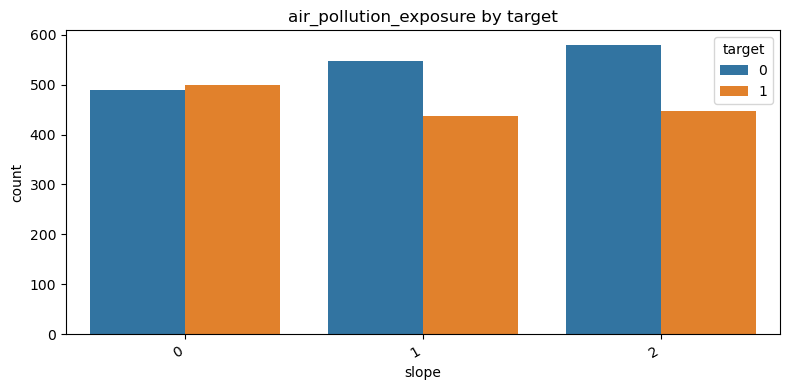

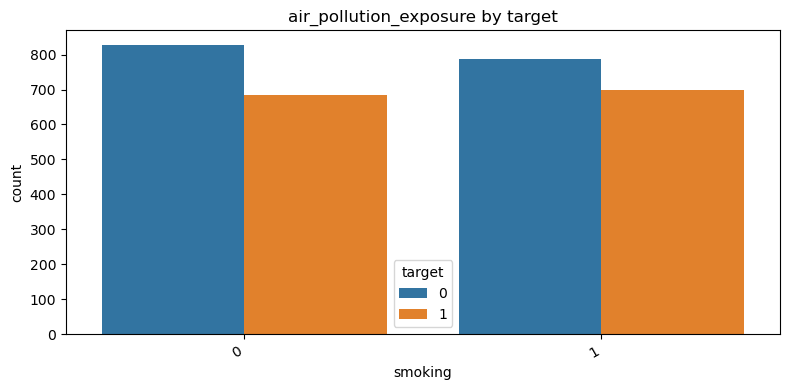

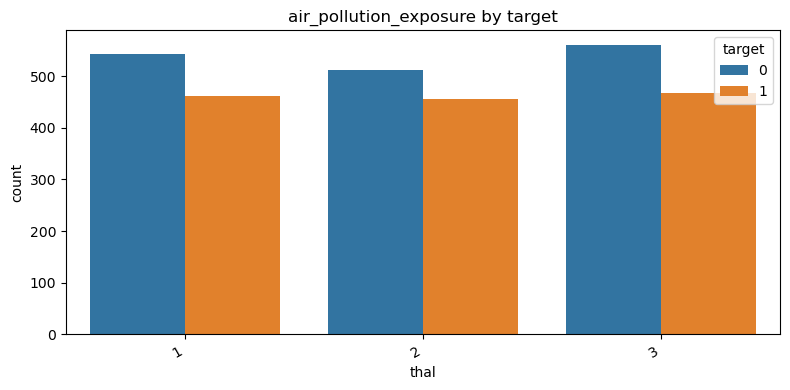

In [30]:
# Step - 3 : Plot all columns by target (excluding patient_id and age)
#   - Histogram by target
#   - Count plot for each column vs target
columns = [c for c in df.columns if c not in exclude_columns_for_plots]

num_columns = [c for c in columns if pd.api.types.is_numeric_dtype(df[c])]
cat_columns = [c for c in columns if c not in num_columns]

# Treat spread numbers like 0 , 1 [or] 0, 1, 2, 2 as unique values and not continious
cat_like = sorted(set(cat_columns + [c for c in num_columns if df[c].nunique(dropna=True) <= 10]))
true_num = [c for c in num_columns if c not in cat_like]

print("\nNumeric columns (true):", true_num)
print("\nCategorical-like columns:", cat_like)

# Numeric plots (one at a time so they are NOT tiny)
for columns in true_num:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=columns, hue=target_col, kde=True, element="step")
    plt.title(f"{columns} distribution by target")
    plt.tight_layout()
    plt.show()

# Categorical plots
for col in cat_like:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue=target_col)
    plt.title(f"{columns} by target")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

***Step - 4 : Since it is evident that no one particular vital is impacting the target***

now consider multiple factors impactign the target, following columns are considered for combinational analysis

**1. Cholesterol #  is a known clinical indicator for heart disease.**

**2. Blood pressure showed clearer separation between low-risk and high-risk patients**

**3. Diabetes is a major long-term risk factor for heart disease**

**4. Smoking is a commonly recognized lifestyle risk factor for cardiovascular issues**

**5. Obesity is known clinical indicator and linked to heart issues**

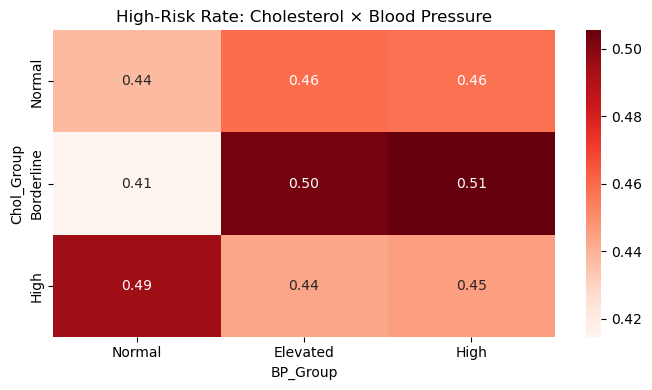


Top 10 highest-risk profiles:


,Profile,target
18,"High Chol, Normal BP, No Lifestyle Risk Factors",0.625000
15,"Borderline Chol, High BP, No Lifestyle Risk Fa...",0.589744
12,"Borderline Chol, Elevated BP, No Lifestyle Ris...",0.560000
19,"High Chol, Normal BP, One Lifestyle Risk Factor",0.526667
17,"Borderline Chol, High BP, Multiple Lifestyle R...",0.518919
4,"Normal Chol, Elevated BP, One Lifestyle Risk F...",0.500000
14,"Borderline Chol, Elevated BP, Multiple Lifesty...",0.500000
7,"Normal Chol, High BP, One Lifestyle Risk Factor",0.491429
1,"Normal Chol, Normal BP, One Lifestyle Risk Factor",0.485294
13,"Borderline Chol, Elevated BP, One Lifestyle Ri...",0.483871


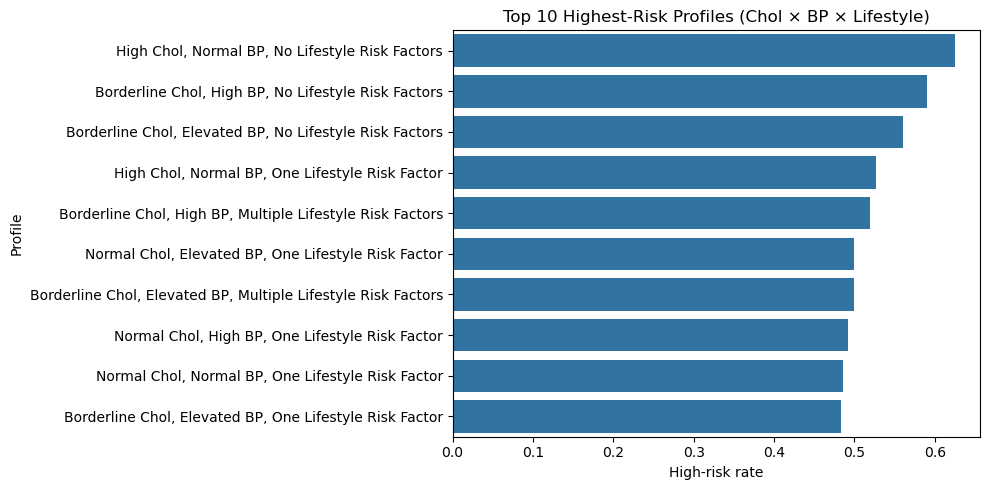

In [31]:
# Step - 4 : Since it is evident that no one particular vital is impacting the target, 
# now consider multiple factors impactign the target
# following columns are considered for combinational analysis
# 1. Cholesterol is a known clinical indicator for heart disease.
# 2. Blood pressure showed clearer separation between low-risk and high-risk patients
# 3. Diabetes is a major long-term risk factor for heart disease
# 4. Smoking is a commonly recognized lifestyle risk factor for cardiovascular issues
# 5. Obesity is known clinical indicator and linked to heart issues 

chol_col = "chol"
bp_col   = "trestbps"
diab_col = "diabetes"
smoke_col = "smoking"
obese_col = "obesity"

needed = [chol_col, bp_col, diab_col, smoke_col, obese_col]
missing = [c for c in needed if c not in df.columns]

if missing:
    print("\nSkipping combination analysis. Missing columns:", missing)
else:
    eda = df.copy()

    # Buckets for cholesterol and BP
    eda["Chol_Group"] = pd.cut(eda[chol_col], [0, 200, 240, 2000], labels=["Normal", "Borderline", "High"])
    eda["BP_Group"]   = pd.cut(eda[bp_col],   [0, 120, 140, 400], labels=["Normal", "Elevated", "High"])

    # Lifestyle group (rename None -> No Risk Factors so it doesn't look like missing data)
    # Assumes columns are 0/1; if not, anything >0 becomes 1.
    eda["diab01"]  = (eda[diab_col].astype(float)  > 0).astype(int)
    eda["smoke01"] = (eda[smoke_col].astype(float) > 0).astype(int)
    eda["obese01"] = (eda[obese_col].astype(float) > 0).astype(int)

    eda["Lifestyle_Score"] = eda["diab01"] + eda["smoke01"] + eda["obese01"]
    eda["Lifestyle_Group"] = pd.cut(
        eda["Lifestyle_Score"], [-1, 0, 1, 3],
        labels=[
            "No Lifestyle Risk Factors",
            "One Lifestyle Risk Factor",
            "Multiple Lifestyle Risk Factors"
        ]
    )

    # Heatmap: Chol × BP (use observed=True to remove pandas warning)
    heat = (
        eda.groupby(["Chol_Group", "BP_Group"], observed=True)[target_col]
           .mean()
           .unstack()
    )

    plt.figure(figsize=(7,4))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="Reds")
    plt.title("High-Risk Rate: Cholesterol × Blood Pressure")
    plt.tight_layout()
    plt.show()

    # Top 10 Profiles: Chol × BP × Lifestyle
    tbl = (
        eda.groupby(["Chol_Group", "BP_Group", "Lifestyle_Group"], observed=True)[target_col]
           .mean()
           .reset_index()
           .sort_values(target_col, ascending=False)
    )

    tbl["Profile"] = (
        tbl["Chol_Group"].astype(str) + " Chol, " +
        tbl["BP_Group"].astype(str) + " BP, " +
        tbl["Lifestyle_Group"].astype(str)
    )

    top10 = tbl.head(10)
    print("\nTop 10 highest-risk profiles:")
    display(top10[["Profile", target_col]])

    plt.figure(figsize=(10,5))
    sns.barplot(data=top10, x=target_col, y="Profile")
    plt.title("Top 10 Highest-Risk Profiles (Chol × BP × Lifestyle)")
    plt.xlabel("High-risk rate")
    plt.tight_layout()
    plt.show()

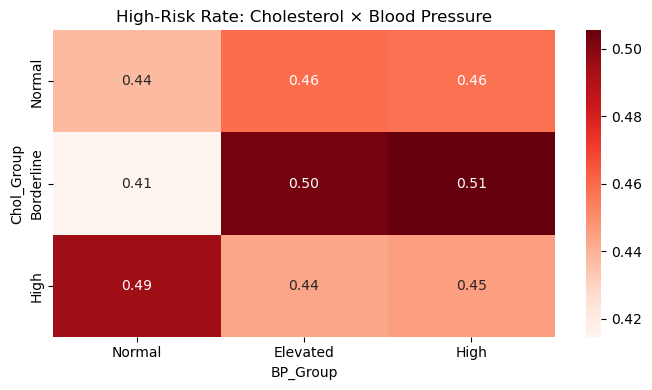


Top 10 risk profiles:


,Profile,target
18,"High Chol, Normal BP, No Lifestyle Risk Factors",0.625000
15,"Borderline Chol, High BP, No Lifestyle Risk Fa...",0.589744
12,"Borderline Chol, Elevated BP, No Lifestyle Ris...",0.560000
19,"High Chol, Normal BP, One Lifestyle Risk Factor",0.526667
17,"Borderline Chol, High BP, Multiple Lifestyle R...",0.518919
4,"Normal Chol, Elevated BP, One Lifestyle Risk F...",0.500000
14,"Borderline Chol, Elevated BP, Multiple Lifesty...",0.500000
7,"Normal Chol, High BP, One Lifestyle Risk Factor",0.491429
1,"Normal Chol, Normal BP, One Lifestyle Risk Factor",0.485294
13,"Borderline Chol, Elevated BP, One Lifestyle Ri...",0.483871


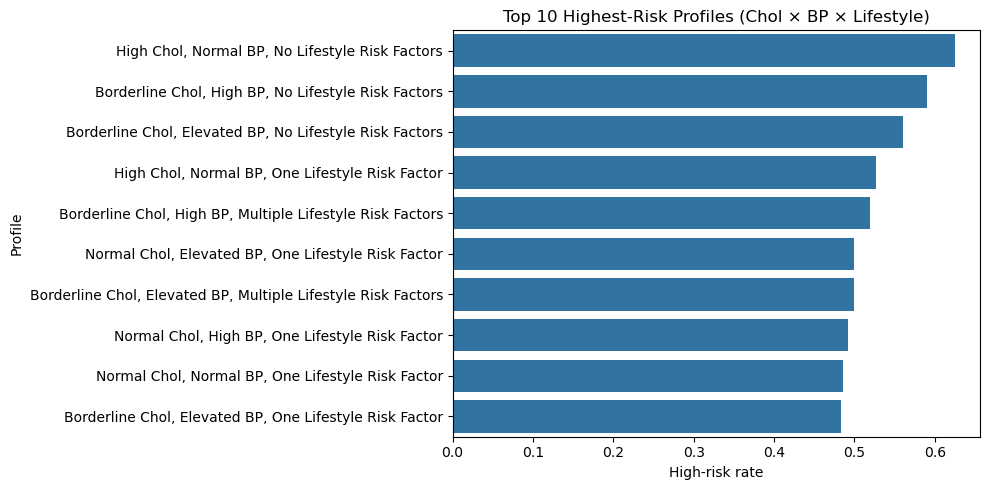

In [32]:
# -----------------------------
# Step 5:  Combination analysis (cholesterol + BP + lifestyle)
# -----------------------------
chol_col = "chol"
bp_col = "trestbps"
diab_col = "diabetes"
smoke_col = "smoking"
obese_col = "obesity"

needed = [chol_col, bp_col, diab_col, smoke_col, obese_col]
missing = [c for c in needed if c not in df.columns]

if missing:
    print("Missing columns for combination analysis:", missing)
else:
    analysis_data = df.copy()

    # Buckets for cholesterol and BP
    analysis_data["Chol_Group"] = pd.cut(analysis_data[chol_col], [0, 200, 240, 2000], labels=["Normal", "Borderline", "High"])
    analysis_data["BP_Group"] = pd.cut(analysis_data[bp_col], [0, 120, 140, 400], labels=["Normal", "Elevated", "High"])

    # Lifestyle score (assumes 0/1 columns)
    analysis_data["Lifestyle_Score"] = analysis_data[diab_col] + analysis_data[smoke_col] + analysis_data[obese_col]
    analysis_data["Lifestyle_Group"] = pd.cut(
        analysis_data["Lifestyle_Score"], [-1, 0, 1, 3],
        labels=[
            "No Lifestyle Risk Factors",
            "One Lifestyle Risk Factor",
            "Multiple Lifestyle Risk Factors"
        ]
    )

    # Heatmap: Chol × BP
    heatmap = (
    analysis_data.groupby(["Chol_Group", "BP_Group"], observed=True)[target_col]
       .mean()
       .unstack()
    )
    plt.figure(figsize=(7,4))
    sns.heatmap(heatmap, annot=True, fmt=".2f", cmap="Reds")
    plt.title("High-Risk Rate: Cholesterol × Blood Pressure")
    plt.tight_layout()
    plt.show()

    # Top 10 profiles: Chol × BP × Lifestyle
    top_10 = (
        analysis_data.groupby(["Chol_Group", "BP_Group", "Lifestyle_Group"], observed=True)[target_col]
           .mean()
           .reset_index()
    )
    top_10 = top_10.sort_values(target_col, ascending=False)

    top_10["Profile"] = (
        top_10["Chol_Group"].astype(str) + " Chol, " +
        top_10["BP_Group"].astype(str) + " BP, " +
        top_10["Lifestyle_Group"].astype(str)
    )

    top10 = top_10.head(10)
    print("\nTop 10 risk profiles:")
    display(top10[["Profile", target_col]])

    plt.figure(figsize=(10,5))
    sns.barplot(data=top10, x=target_col, y="Profile")
    plt.title("Top 10 Highest-Risk Profiles (Chol × BP × Lifestyle)")
    plt.xlabel("High-risk rate")
    plt.tight_layout()
    plt.show()

***Baseline : Decision Tree***

- Trained a simple Decision Tree model as a baseline.
- Evaluated the model using accuracy, precision, recall, and F1-score.
- The model achieved limited accuracy, which suggests underfitting.



--- Decision Tree (Validation) ---
Accuracy : 0.528
Precision: 0.3333333333333333
Recall   : 0.023121387283236993
F1       : 0.043243243243243246
AUC      : 0.4946345790648428


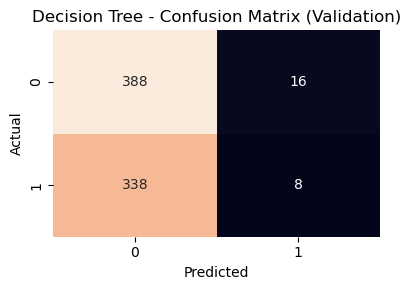


--- Decision Tree (Test) ---
Accuracy : 0.5311111111111111
Precision: 0.3333333333333333
Recall   : 0.014423076923076924
F1       : 0.027649769585253458
AUC      : 0.5156349332485696

Classification report (Test):
              precision    recall  f1-score   support

           0       0.54      0.98      0.69       242
           1       0.33      0.01      0.03       208

    accuracy                           0.53       450
   macro avg       0.43      0.49      0.36       450
weighted avg       0.44      0.53      0.38       450



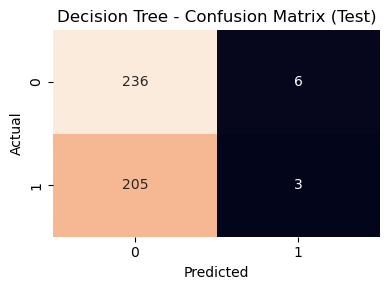

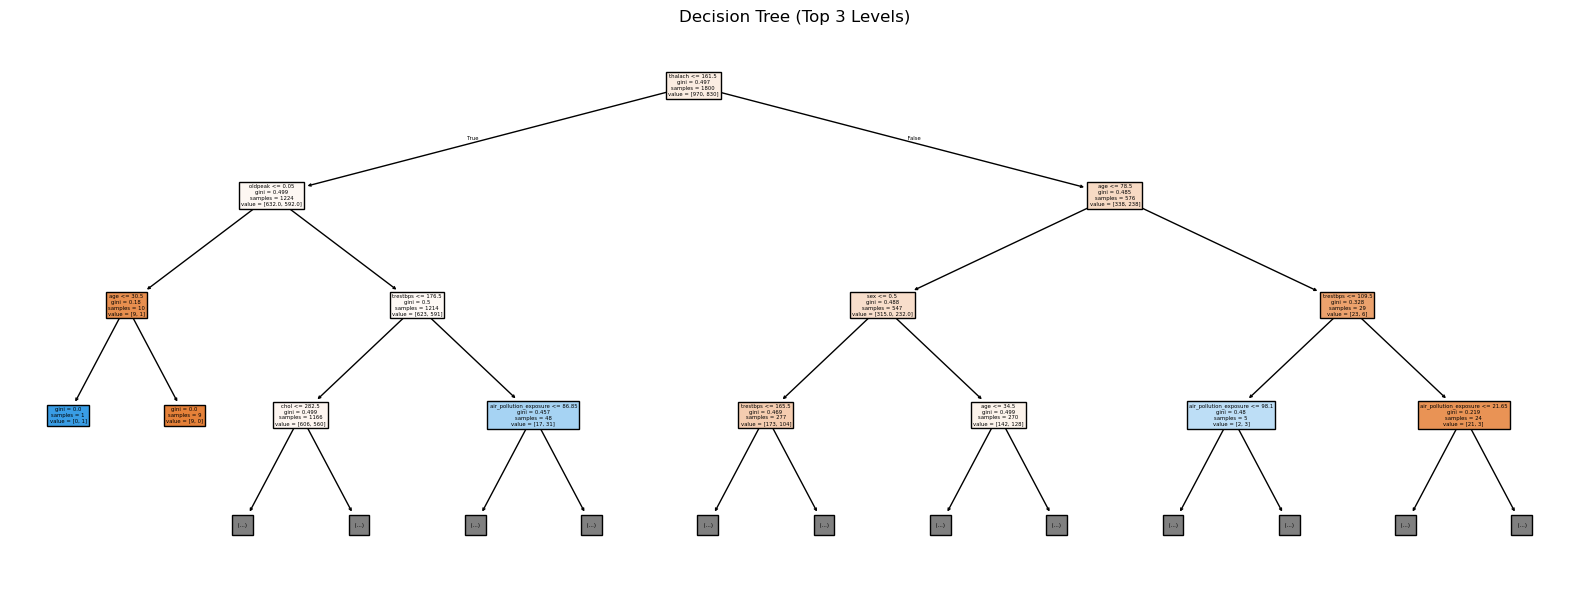

In [33]:
# -----------------------------
# Step 6: Model Training: Decision Tree (60/25/15 split)
# -----------------------------
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

val_pred_dt = dt.predict(X_val)
val_proba_dt = dt.predict_proba(X_val)[:, 1]

print("\n--- Decision Tree (Validation) ---")
print("Accuracy :", accuracy_score(y_val, val_pred_dt))
print("Precision:", precision_score(y_val, val_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_dt, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_dt, zero_division=0))
print("AUC      :", roc_auc_score(y_val, val_proba_dt))

cm_dt = confusion_matrix(y_val, val_pred_dt)
plt.figure(figsize=(4,3))
sns.heatmap(cm_dt, annot=True, fmt="d", cbar=False)
plt.title("Decision Tree - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

test_pred_dt = dt.predict(X_test)
test_proba_dt = dt.predict_proba(X_test)[:, 1]

print("\n--- Decision Tree (Test) ---")
print("Accuracy :", accuracy_score(y_test, test_pred_dt))
print("Precision:", precision_score(y_test, test_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_dt, zero_division=0))
print("F1       :", f1_score(y_test, test_pred_dt, zero_division=0))
print("AUC      :", roc_auc_score(y_test, test_proba_dt))
print("\nClassification report (Test):")
print(classification_report(y_test, test_pred_dt, zero_division=0))

cm2_dt = confusion_matrix(y_test, test_pred_dt)
plt.figure(figsize=(4,3))
sns.heatmap(cm2_dt, annot=True, fmt="d", cbar=False)
plt.title("Decision Tree - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16,6))
plot_tree(dt, feature_names=X.columns, filled=True, max_depth=3)
plt.title("Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

***Logistic Regression***
    
- This model predicts heart-attack risk using a linear combination of features.
- It is easy to understand and interpret.
- However, it assumes mostly linear relationships between features and the target.
- Because healthcare data often contains complex interactions, the model showed moderate performance.


--- Logistic Regression (Validation) ---
Accuracy : 0.5133333333333333
Precision: 0.45077720207253885
Recall   : 0.2514450867052023
F1       : 0.3228200371057514
AUC      : 0.5035697933955245


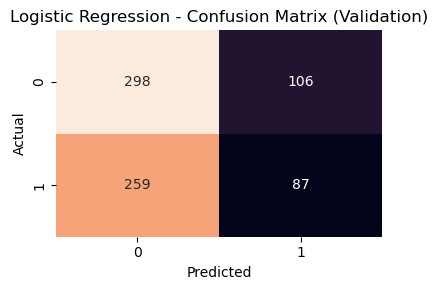


--- Logistic Regression (Test) ---
Accuracy : 0.5555555555555556
Precision: 0.5338983050847458
Recall   : 0.30288461538461536
F1       : 0.38650306748466257
AUC      : 0.555685791481246

Classification report (Test):
              precision    recall  f1-score   support

           0       0.56      0.77      0.65       242
           1       0.53      0.30      0.39       208

    accuracy                           0.56       450
   macro avg       0.55      0.54      0.52       450
weighted avg       0.55      0.56      0.53       450



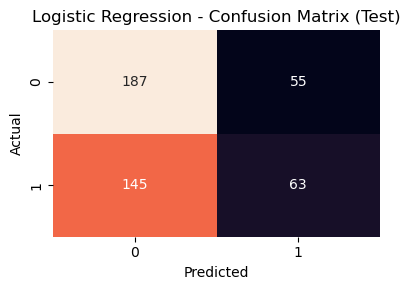

In [34]:
# -----------------------------
# Step 7: Model Training: Logistic Regression (60/25/15 split)
# -----------------------------

lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

lr.fit(X_train, y_train)

# Validate
val_pred_lr = lr.predict(X_val)
val_proba_lr = lr.predict_proba(X_val)[:, 1]

print("\n--- Logistic Regression (Validation) ---")
print("Accuracy :", accuracy_score(y_val, val_pred_lr))
print("Precision:", precision_score(y_val, val_pred_lr, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_lr, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_lr, zero_division=0))
print("AUC      :", roc_auc_score(y_val, val_proba_lr))

cm_lr = confusion_matrix(y_val, val_pred_lr)
plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt="d", cbar=False)
plt.title("Logistic Regression - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Test
test_pred_lr = lr.predict(X_test)
test_proba_lr = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression (Test) ---")
print("Accuracy :", accuracy_score(y_test, test_pred_lr))
print("Precision:", precision_score(y_test, test_pred_lr, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_lr, zero_division=0))
print("F1       :", f1_score(y_test, test_pred_lr, zero_division=0))
print("AUC      :", roc_auc_score(y_test, test_proba_lr))
print("\nClassification report (Test):")
print(classification_report(y_test, test_pred_lr, zero_division=0))

cm2_lr = confusion_matrix(y_test, test_pred_lr)
plt.figure(figsize=(4,3))
sns.heatmap(cm2_lr, annot=True, fmt="d", cbar=False)
plt.title("Logistic Regression - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

***Polynomial Logistic Regression:***

- Added Polynomial Features (degree = 2) before Logistic Regression.
- This allows the model to capture interaction effects between features.
- Compared to the basic Logistic Regression, this model improved recall, meaning it identified more high-risk patients.
- This shows that feature interactions are important for predicting heart-attack risk.


--- Polynomial Logistic Regression (Validation) ---
Accuracy : 0.5186666666666667
Precision: 0.47706422018348627
Recall   : 0.4508670520231214
F1       : 0.4635958395245171
AUC      : 0.5109597664968809


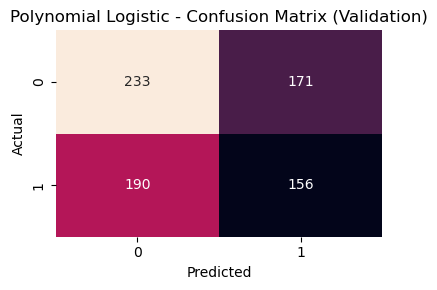


--- Polynomial Logistic Regression (Test) ---
Accuracy : 0.5066666666666667
Precision: 0.465
Recall   : 0.44711538461538464
F1       : 0.45588235294117646
AUC      : 0.5253496503496503

Classification report (Test):
              precision    recall  f1-score   support

           0       0.54      0.56      0.55       242
           1       0.47      0.45      0.46       208

    accuracy                           0.51       450
   macro avg       0.50      0.50      0.50       450
weighted avg       0.51      0.51      0.51       450



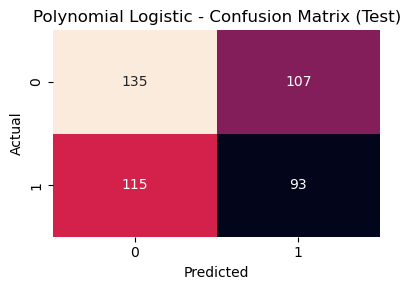

In [35]:
# ----------------------------------------------------------
# Step 8: Model Training: Polynomial Logistic Regression (degree=2)
# ----------------------------------------------------------
poly_lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

poly_lr.fit(X_train, y_train)

# Validate
val_pred_poly = poly_lr.predict(X_val)
val_proba_poly = poly_lr.predict_proba(X_val)[:, 1]

print("\n--- Polynomial Logistic Regression (Validation) ---")
print("Accuracy :", accuracy_score(y_val, val_pred_poly))
print("Precision:", precision_score(y_val, val_pred_poly, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_poly, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_poly, zero_division=0))
print("AUC      :", roc_auc_score(y_val, val_proba_poly))

cm_poly = confusion_matrix(y_val, val_pred_poly)
plt.figure(figsize=(4,3))
sns.heatmap(cm_poly, annot=True, fmt="d", cbar=False)
plt.title("Polynomial Logistic - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Test
test_pred_poly = poly_lr.predict(X_test)
test_proba_poly = poly_lr.predict_proba(X_test)[:, 1]

print("\n--- Polynomial Logistic Regression (Test) ---")
print("Accuracy :", accuracy_score(y_test, test_pred_poly))
print("Precision:", precision_score(y_test, test_pred_poly, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_poly, zero_division=0))
print("F1       :", f1_score(y_test, test_pred_poly, zero_division=0))
print("AUC      :", roc_auc_score(y_test, test_proba_poly))
print("\nClassification report (Test):")
print(classification_report(y_test, test_pred_poly, zero_division=0))

cm2_poly = confusion_matrix(y_test, test_pred_poly)
plt.figure(figsize=(4,3))
sns.heatmap(cm2_poly, annot=True, fmt="d", cbar=False)
plt.title("Polynomial Logistic - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

***Random Forest***
- Random Forest is an ensemble method that builds many decision trees and combines their predictions.
- It automatically captures non-linear relationships and feature interactions.
- Compared to a single Decision Tree, Random Forest produced more stable and better overall performance.


--- Random Forest (Validation) ---
Accuracy : 0.5186666666666667
Precision: 0.4623115577889447
Recall   : 0.2658959537572254
F1       : 0.3376146788990826
AUC      : 0.5028615578320839


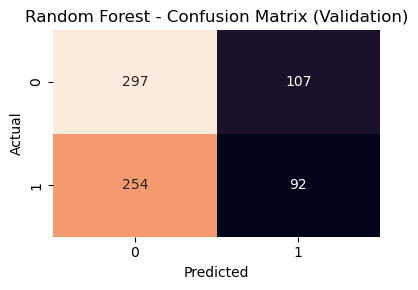


--- Random Forest (Test) ---
Accuracy : 0.5622222222222222
Precision: 0.5401459854014599
Recall   : 0.3557692307692308
F1       : 0.4289855072463768
AUC      : 0.5626986649713922

Classification report (Test):
              precision    recall  f1-score   support

           0       0.57      0.74      0.65       242
           1       0.54      0.36      0.43       208

    accuracy                           0.56       450
   macro avg       0.56      0.55      0.54       450
weighted avg       0.56      0.56      0.55       450



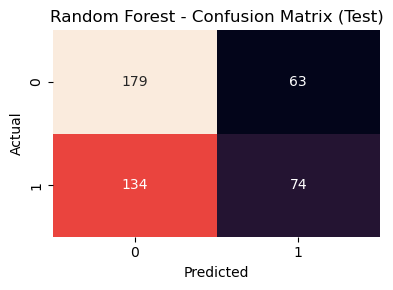

In [36]:
# ----------------------------------------------------------
# Step 9: Model Training: Random Forest (60/25/15 split)
# ----------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Validate
val_pred_rf = rf.predict(X_val)
val_proba_rf = rf.predict_proba(X_val)[:, 1]

print("\n--- Random Forest (Validation) ---")
print("Accuracy :", accuracy_score(y_val, val_pred_rf))
print("Precision:", precision_score(y_val, val_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_rf, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_rf, zero_division=0))
print("AUC      :", roc_auc_score(y_val, val_proba_rf))

cm_rf = confusion_matrix(y_val, val_pred_rf)
plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt="d", cbar=False)
plt.title("Random Forest - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Test
test_pred_rf = rf.predict(X_test)
test_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n--- Random Forest (Test) ---")
print("Accuracy :", accuracy_score(y_test, test_pred_rf))
print("Precision:", precision_score(y_test, test_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_rf, zero_division=0))
print("F1       :", f1_score(y_test, test_pred_rf, zero_division=0))
print("AUC      :", roc_auc_score(y_test, test_proba_rf))
print("\nClassification report (Test):")
print(classification_report(y_test, test_pred_rf, zero_division=0))

cm2_rf = confusion_matrix(y_test, test_pred_rf)
plt.figure(figsize=(4,3))
sns.heatmap(cm2_rf, annot=True, fmt="d", cbar=False)
plt.title("Random Forest - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

***Gradient Boosting***
    
- Gradient Boosting builds decision trees sequentially, where each new tree learns from the errors of the previous trees.
- It performs well for structured healthcare datasets because it can capture non-linear relationships and interactions between multiple risk factors.
- In this project, Gradient Boosting achieved strong overall ranking performance (high AUC) and maintained balanced Accuracy, Precision, and Recall.
- It serves as a reliable ensemble benchmark model for comparison.


--- Gradient Boosting (Validation) ---
Accuracy : 0.5386666666666666
Precision: 0.5
Recall   : 0.3670520231213873
F1       : 0.42333333333333334
AUC      : 0.525167401133177


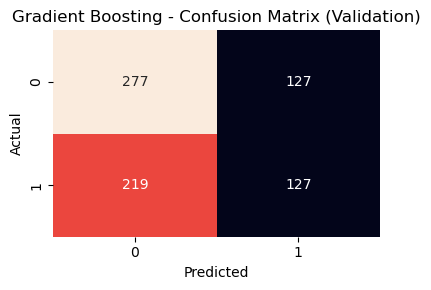


--- Gradient Boosting (Test) ---
Accuracy : 0.5622222222222222
Precision: 0.5413533834586466
Recall   : 0.34615384615384615
F1       : 0.4222873900293255
AUC      : 0.5976041004450096


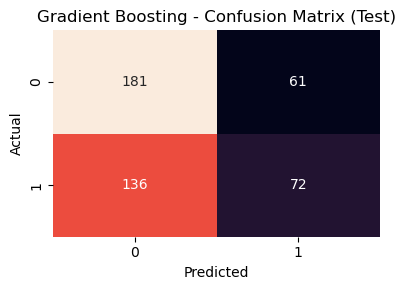

In [37]:
# ----------------------------------------------------------
# Step 10: Model Training: Gradient Boosting Classifier
# ----------------------------------------------------------

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

val_pred_gb = gb.predict(X_val)
val_proba_gb = gb.predict_proba(X_val)[:, 1]

print("\n--- Gradient Boosting (Validation) ---")
print("Accuracy :", accuracy_score(y_val, val_pred_gb))
print("Precision:", precision_score(y_val, val_pred_gb, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_gb, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_gb, zero_division=0))
print("AUC      :", roc_auc_score(y_val, val_proba_gb))

cm_gb = confusion_matrix(y_val, val_pred_gb)
plt.figure(figsize=(4,3))
sns.heatmap(cm_gb, annot=True, fmt="d", cbar=False)
plt.title("Gradient Boosting - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

test_pred_gb = gb.predict(X_test)
test_proba_gb = gb.predict_proba(X_test)[:, 1]

print("\n--- Gradient Boosting (Test) ---")
print("Accuracy :", accuracy_score(y_test, test_pred_gb))
print("Precision:", precision_score(y_test, test_pred_gb, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_gb, zero_division=0))
print("F1       :", f1_score(y_test, test_pred_gb, zero_division=0))
print("AUC      :", roc_auc_score(y_test, test_proba_gb))

cm2_gb = confusion_matrix(y_test, test_pred_gb)
plt.figure(figsize=(4,3))
sns.heatmap(cm2_gb, annot=True, fmt="d", cbar=False)
plt.title("Gradient Boosting - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

***XGBoost***

- XGBoost (Extreme Gradient Boosting) is an optimized implementation of the Gradient Boosting algorithm that improves training efficiency and predictive performance.
- In this project, XGBoost achieved the highest Recall, meaning it detected more patients who are at high risk of heart attack.
- It also maintained competitive AUC and Accuracy, indicating strong overall predictive capability.


--- XGBoost (Validation) ---
Accuracy : 0.5066666666666667
Precision: 0.4602649006622517
Recall   : 0.40173410404624277
F1       : 0.42901234567901236
AUC      : 0.49813283351456533


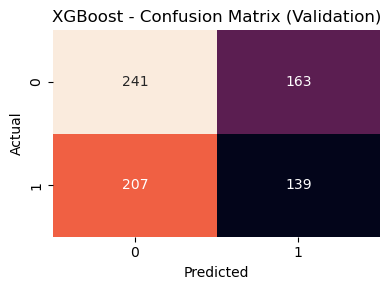


--- XGBoost (Test) ---
Accuracy : 0.5644444444444444
Precision: 0.532967032967033
Recall   : 0.46634615384615385
F1       : 0.49743589743589745
AUC      : 0.5546130006357279


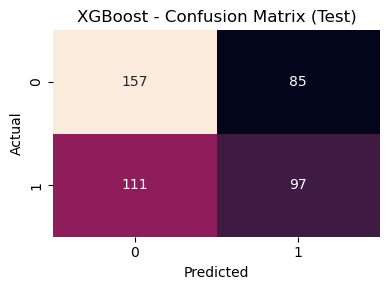

In [38]:
# ============================================================
# Step 11: Model Training: XGBoost  [https://www.ischool.berkeley.edu/projects/2025/deepbeauty-ai]
# ============================================================

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

val_pred_xgb = xgb.predict(X_val)
val_proba_xgb = xgb.predict_proba(X_val)[:, 1]

print("\n--- XGBoost (Validation) ---")
print("Accuracy :", accuracy_score(y_val, val_pred_xgb))
print("Precision:", precision_score(y_val, val_pred_xgb, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_xgb, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_xgb, zero_division=0))
print("AUC      :", roc_auc_score(y_val, val_proba_xgb))

cm_xgb = confusion_matrix(y_val, val_pred_xgb)
plt.figure(figsize=(4,3))
sns.heatmap(cm_xgb, annot=True, fmt="d", cbar=False)
plt.title("XGBoost - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

test_pred_xgb = xgb.predict(X_test)
test_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n--- XGBoost (Test) ---")
print("Accuracy :", accuracy_score(y_test, test_pred_xgb))
print("Precision:", precision_score(y_test, test_pred_xgb, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred_xgb, zero_division=0))
print("F1       :", f1_score(y_test, test_pred_xgb, zero_division=0))
print("AUC      :", roc_auc_score(y_test, test_proba_xgb))

cm2_xgb = confusion_matrix(y_test, test_pred_xgb)
plt.figure(figsize=(4,3))
sns.heatmap(cm2_xgb, annot=True, fmt="d", cbar=False)
plt.title("XGBoost - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1,AUC
4,Gradient Boosting,0.562222,0.541353,0.346154,0.422287,0.597604
3,Random Forest,0.562222,0.540146,0.355769,0.428986,0.562699
1,Logistic Regression,0.555556,0.533898,0.302885,0.386503,0.555686
5,XGBoost,0.564444,0.532967,0.466346,0.497436,0.554613
2,Polynomial Logistic (deg=2),0.506667,0.465000,0.447115,0.455882,0.525350
0,Decision Tree,0.531111,0.333333,0.014423,0.027650,0.515635


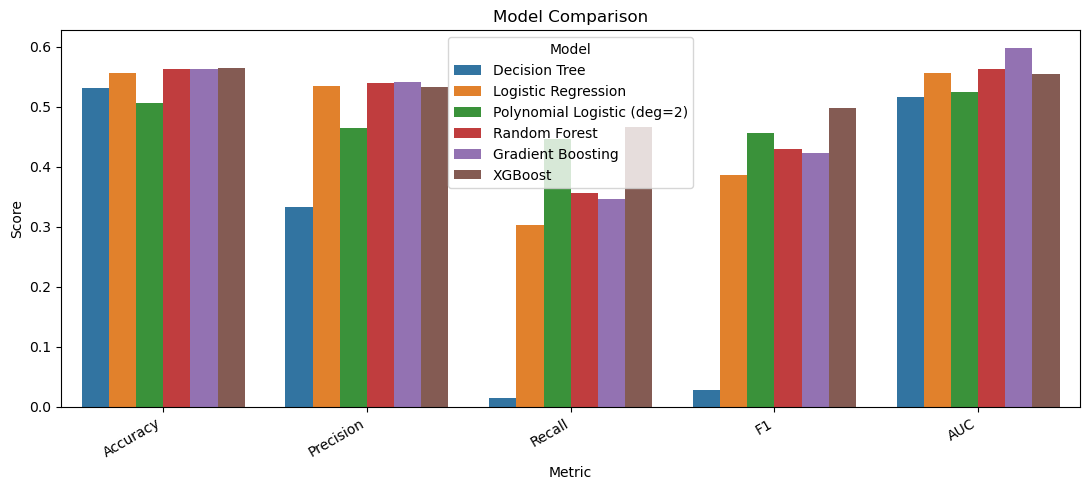

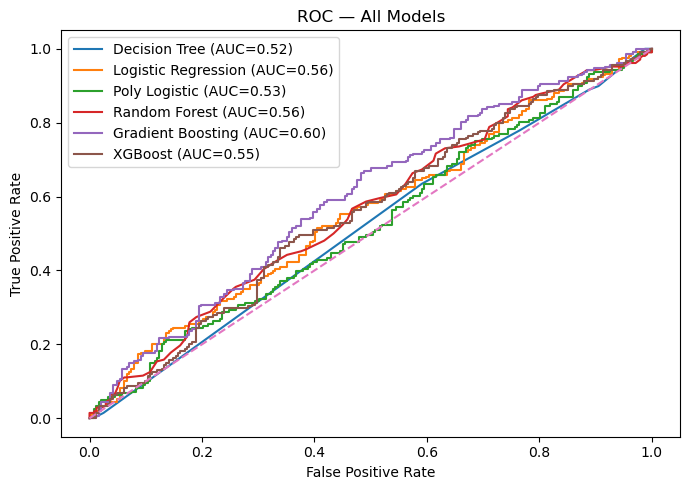

In [39]:
# ============================================================
# 11) Final Comparison Table + Visuals
# ============================================================
comparison = pd.DataFrame([
    ["Decision Tree",
     accuracy_score(y_test, test_pred_dt),
     precision_score(y_test, test_pred_dt, zero_division=0),
     recall_score(y_test, test_pred_dt, zero_division=0),
     f1_score(y_test, test_pred_dt, zero_division=0),
     roc_auc_score(y_test, test_proba_dt)],

    ["Logistic Regression",
     accuracy_score(y_test, test_pred_lr),
     precision_score(y_test, test_pred_lr, zero_division=0),
     recall_score(y_test, test_pred_lr, zero_division=0),
     f1_score(y_test, test_pred_lr, zero_division=0),
     roc_auc_score(y_test, test_proba_lr)],

    ["Polynomial Logistic (deg=2)",
     accuracy_score(y_test, test_pred_poly),
     precision_score(y_test, test_pred_poly, zero_division=0),
     recall_score(y_test, test_pred_poly, zero_division=0),
     f1_score(y_test, test_pred_poly, zero_division=0),
     roc_auc_score(y_test, test_proba_poly)],

    ["Random Forest",
     accuracy_score(y_test, test_pred_rf),
     precision_score(y_test, test_pred_rf, zero_division=0),
     recall_score(y_test, test_pred_rf, zero_division=0),
     f1_score(y_test, test_pred_rf, zero_division=0),
     roc_auc_score(y_test, test_proba_rf)],

    ["Gradient Boosting",
     accuracy_score(y_test, test_pred_gb),
     precision_score(y_test, test_pred_gb, zero_division=0),
     recall_score(y_test, test_pred_gb, zero_division=0),
     f1_score(y_test, test_pred_gb, zero_division=0),
     roc_auc_score(y_test, test_proba_gb)]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])

if xgb_available:
    comparison = pd.concat([comparison, pd.DataFrame([[
        "XGBoost",
        accuracy_score(y_test, test_pred_xgb),
        precision_score(y_test, test_pred_xgb, zero_division=0),
        recall_score(y_test, test_pred_xgb, zero_division=0),
        f1_score(y_test, test_pred_xgb, zero_division=0),
        roc_auc_score(y_test, test_proba_xgb)
    ]], columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])], ignore_index=True)

print("\n=== Model Comparison ===")
display(comparison.sort_values("AUC", ascending=False))

# Bar chart
comp_long = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11,5))
sns.barplot(data=comp_long, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(7,5))

fpr, tpr, _ = roc_curve(y_test, test_proba_dt)
plt.plot(fpr, tpr, label=f"Decision Tree (AUC={roc_auc_score(y_test, test_proba_dt):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_lr)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, test_proba_lr):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_poly)
plt.plot(fpr, tpr, label=f"Poly Logistic (AUC={roc_auc_score(y_test, test_proba_poly):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_rf)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={roc_auc_score(y_test, test_proba_rf):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_gb)
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC={roc_auc_score(y_test, test_proba_gb):.2f})")

if xgb_available:
    fpr, tpr, _ = roc_curve(y_test, test_proba_xgb)
    plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, test_proba_xgb):.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

***Performance Metrics Comparison***

To evaluate the performance and identify suitable model, following five metrics are used -
- Accuracy
- Precision
- Recall
- F1-Score
- AUC


=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1,AUC
4,Gradient Boosting,0.562222,0.541353,0.346154,0.422287,0.597604
3,Random Forest,0.562222,0.540146,0.355769,0.428986,0.562699
1,Logistic Regression,0.555556,0.533898,0.302885,0.386503,0.555686
5,XGBoost,0.564444,0.532967,0.466346,0.497436,0.554613
2,Polynomial Logistic (deg=2),0.506667,0.465000,0.447115,0.455882,0.525350
0,Decision Tree,0.531111,0.333333,0.014423,0.027650,0.515635


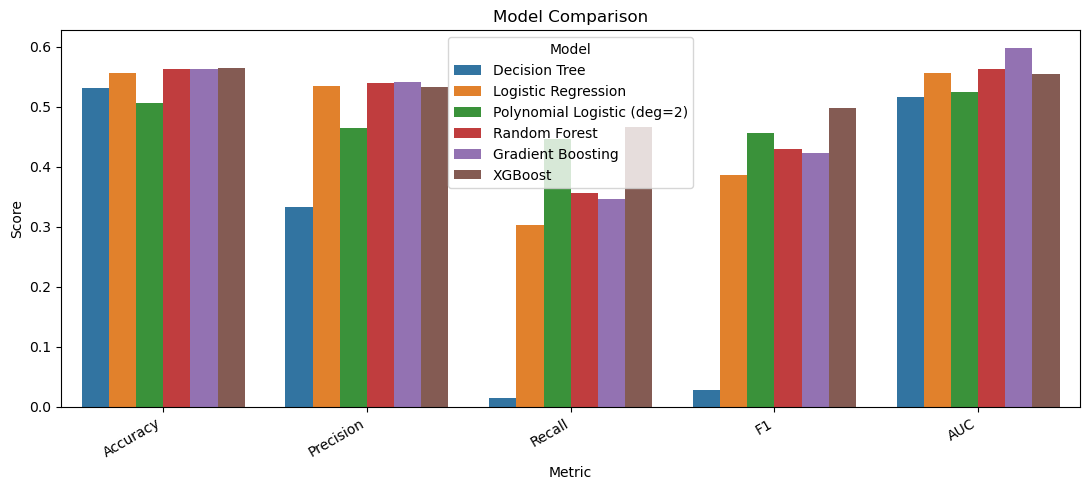

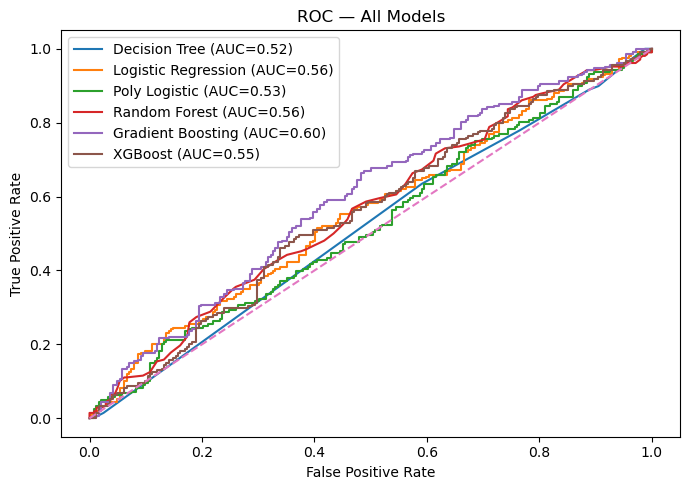

In [39]:
# ============================================================
# 11) Final Comparison Table + Visuals
# ============================================================
comparison = pd.DataFrame([
    ["Decision Tree",
     accuracy_score(y_test, test_pred_dt),
     precision_score(y_test, test_pred_dt, zero_division=0),
     recall_score(y_test, test_pred_dt, zero_division=0),
     f1_score(y_test, test_pred_dt, zero_division=0),
     roc_auc_score(y_test, test_proba_dt)],

    ["Logistic Regression",
     accuracy_score(y_test, test_pred_lr),
     precision_score(y_test, test_pred_lr, zero_division=0),
     recall_score(y_test, test_pred_lr, zero_division=0),
     f1_score(y_test, test_pred_lr, zero_division=0),
     roc_auc_score(y_test, test_proba_lr)],

    ["Polynomial Logistic (deg=2)",
     accuracy_score(y_test, test_pred_poly),
     precision_score(y_test, test_pred_poly, zero_division=0),
     recall_score(y_test, test_pred_poly, zero_division=0),
     f1_score(y_test, test_pred_poly, zero_division=0),
     roc_auc_score(y_test, test_proba_poly)],

    ["Random Forest",
     accuracy_score(y_test, test_pred_rf),
     precision_score(y_test, test_pred_rf, zero_division=0),
     recall_score(y_test, test_pred_rf, zero_division=0),
     f1_score(y_test, test_pred_rf, zero_division=0),
     roc_auc_score(y_test, test_proba_rf)],

    ["Gradient Boosting",
     accuracy_score(y_test, test_pred_gb),
     precision_score(y_test, test_pred_gb, zero_division=0),
     recall_score(y_test, test_pred_gb, zero_division=0),
     f1_score(y_test, test_pred_gb, zero_division=0),
     roc_auc_score(y_test, test_proba_gb)]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])

if xgb_available:
    comparison = pd.concat([comparison, pd.DataFrame([[
        "XGBoost",
        accuracy_score(y_test, test_pred_xgb),
        precision_score(y_test, test_pred_xgb, zero_division=0),
        recall_score(y_test, test_pred_xgb, zero_division=0),
        f1_score(y_test, test_pred_xgb, zero_division=0),
        roc_auc_score(y_test, test_proba_xgb)
    ]], columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"])], ignore_index=True)

print("\n=== Model Comparison ===")
display(comparison.sort_values("AUC", ascending=False))

# Bar chart
comp_long = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(11,5))
sns.barplot(data=comp_long, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(7,5))

fpr, tpr, _ = roc_curve(y_test, test_proba_dt)
plt.plot(fpr, tpr, label=f"Decision Tree (AUC={roc_auc_score(y_test, test_proba_dt):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_lr)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, test_proba_lr):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_poly)
plt.plot(fpr, tpr, label=f"Poly Logistic (AUC={roc_auc_score(y_test, test_proba_poly):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_rf)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={roc_auc_score(y_test, test_proba_rf):.2f})")

fpr, tpr, _ = roc_curve(y_test, test_proba_gb)
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC={roc_auc_score(y_test, test_proba_gb):.2f})")

if xgb_available:
    fpr, tpr, _ = roc_curve(y_test, test_proba_xgb)
    plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, test_proba_xgb):.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

***Model perfornace Quadrant (Magic Quadrant - AUC vs Recall)***

How to read the Magic Quadrant?
- The horizontal axis represents AUC (overall ranking ability).
- The vertical axis represents Recall (risk detection ability).
- The dashed lines indicate the average AUC and Recall across models.

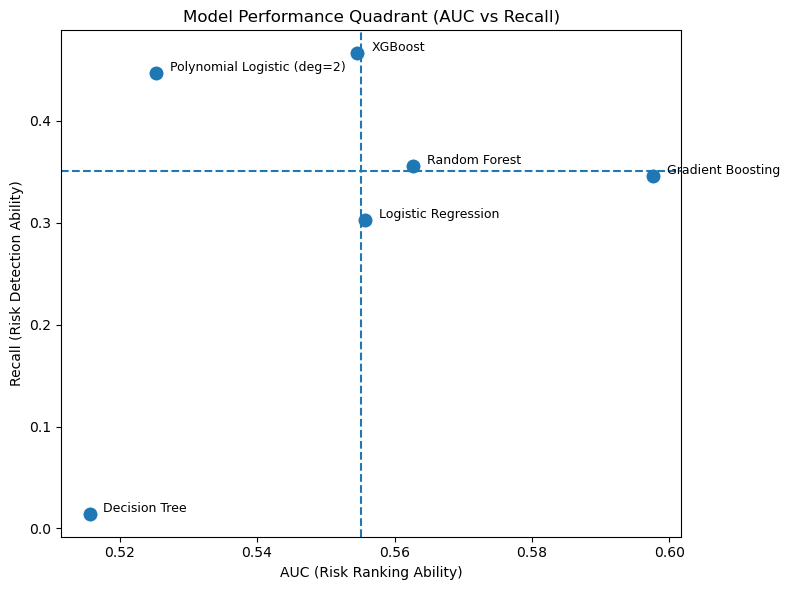

In [40]:
# ----------------------------------------------------------
# Magic Quadrant  (AUC vs Recall)
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(
    data=comparison,
    x="AUC",
    y="Recall",
    s=120
)

# Label each point with model name
for i in range(len(comparison)):
    plt.text(
        comparison["AUC"].iloc[i] + 0.002,
        comparison["Recall"].iloc[i] + 0.002,
        comparison["Model"].iloc[i],
        fontsize=9
    )

# Draw quadrant lines (median split)
auc_mid = comparison["AUC"].median()
recall_mid = comparison["Recall"].median()

plt.axvline(auc_mid, linestyle="--")
plt.axhline(recall_mid, linestyle="--")

plt.title("Model Performance Quadrant (AUC vs Recall)")
plt.xlabel("AUC (Risk Ranking Ability)")
plt.ylabel("Recall (Risk Detection Ability)")
plt.tight_layout()
plt.show()


***Conclusion***

**Recommended model: XGBoost**

Based on comprehensive analysis, XGBoost is recommended as the final model for the heart attack risk prediction system. This recommendation is driven by the following key findings:
- Performance Metrics: While the Gradient Boosting model demonstrated a marginally higher Area Under the Curve (AUC), XGBoost achieved the highest Recall and F1-score across evaluations, which included the performance table and ROC curve analysis.
- Clinical Alignment: Critically, the project's primary objective is the early identification of individuals at high risk of heart attack. This necessitates prioritizing the model's ability to successfully detect as many high-risk cases as possible (high Recall) over small improvements in overall ranking accuracy (AUC).
- Quadrant Analysis & Risk Priorities: Quadrant comparison further supported that XGBoost provided a more favorable balance in identifying true positives, directly aligning with clinical risk priorities where missing a high-risk patient carries significant implications.
  
***Recommended model:***
Considering the critical nature of early detection in preventive healthcare, XGBoost provides the optimal balance between predictive strength and clinical utility for the heart-attack risk prediction. Its superior Recall performance ensures that the system is best positioned to identify and enable intervention with high-risk patients effectively.